In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import fashion_mnist

from sklearn.metrics import classification_report, confusion_matrix

tf.keras.utils.disable_interactive_logging()

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print("Training Data Shape:", x_train.shape)
print("Testing Data Shape :", x_test.shape)

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

Training Data Shape: (60000, 28, 28)
Testing Data Shape : (10000, 28, 28)


In [3]:
# Flatten images 28x28 -> 784

x_train_fnn = x_train.reshape(-1, 784)
x_test_fnn = x_test.reshape(-1, 784)


# Normalize pixel values

x_train_fnn = x_train_fnn / 255.0
x_test_fnn = x_test_fnn / 255.0


print("FNN Training Shape:", x_train_fnn.shape)
print("FNN Testing Shape :", x_test_fnn.shape)

FNN Training Shape: (60000, 784)
FNN Testing Shape : (10000, 784)


In [4]:
model_fnn = keras.Sequential([

    layers.Dense(128, activation="relu", input_shape=(784,)),

    layers.Dropout(0.2),

    layers.Dense(64, activation="relu"),

    layers.Dense(10, activation="softmax")

])


model_fnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


model_fnn.summary()

C:\Users\Lenovo\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
history_fnn = model_fnn.fit(
    x_train_fnn,
    y_train,
    epochs=10,
    validation_split=0.1
)


loss_fnn, acc_fnn = model_fnn.evaluate(
    x_test_fnn,
    y_test
)


print("FNN Test Loss:", loss_fnn)
print("FNN Test Accuracy:", acc_fnn)

FNN Test Loss: 0.34095796942710876
FNN Test Accuracy: 0.8851000070571899


              precision    recall  f1-score   support

           0       0.82      0.86      0.84      1000
           1       0.99      0.97      0.98      1000
           2       0.81      0.80      0.81      1000
           3       0.83      0.94      0.88      1000
           4       0.81      0.81      0.81      1000
           5       0.97      0.96      0.97      1000
           6       0.75      0.64      0.69      1000
           7       0.96      0.93      0.94      1000
           8       0.95      0.97      0.96      1000
           9       0.94      0.97      0.95      1000

    accuracy                           0.89     10000
   macro avg       0.88      0.89      0.88     10000
weighted avg       0.88      0.89      0.88     10000



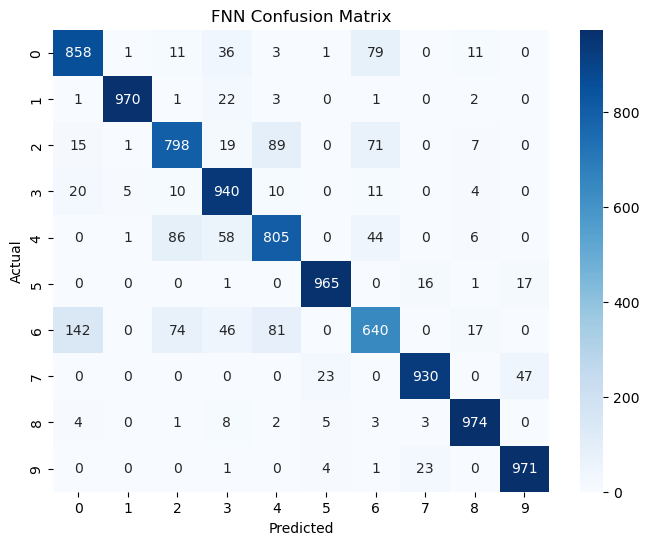

In [7]:
y_pred_fnn = np.argmax(
    model_fnn.predict(x_test_fnn),
    axis=1
)


print(classification_report(
    y_test,
    y_pred_fnn
))


cm_fnn = confusion_matrix(
    y_test,
    y_pred_fnn
)


plt.figure(figsize=(8,6))

sns.heatmap(
    cm_fnn,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("FNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


In [8]:
# Add channel dimension

x_train_cnn = x_train.reshape(
    -1,28,28,1
)

x_test_cnn = x_test.reshape(
    -1,28,28,1
)


# Normalize

x_train_cnn = x_train_cnn / 255.0

x_test_cnn = x_test_cnn / 255.0


print("CNN Training Shape:", x_train_cnn.shape)
print("CNN Testing Shape :", x_test_cnn.shape)

CNN Training Shape: (60000, 28, 28, 1)
CNN Testing Shape : (10000, 28, 28, 1)


In [12]:
model_cnn = keras.Sequential([

    layers.Input(shape=(28,28,1)),

    layers.Conv2D(
        32,
        (3,3),
        activation="relu"
    ),

    layers.MaxPooling2D(
        (2,2)
    ),

    layers.Conv2D(
        64,
        (3,3),
        activation="relu"
    ),

    layers.MaxPooling2D(
        (2,2)
    ),

    layers.Flatten(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.5),

    layers.Dense(
        10,
        activation="softmax"
    )
])


model_cnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


model_cnn.summary()

In [10]:
history_cnn = model_cnn.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.1
)


loss_cnn, acc_cnn = model_cnn.evaluate(
    x_test_cnn,
    y_test
)


print("CNN Test Loss:", loss_cnn)
print("CNN Test Accuracy:", acc_cnn)

CNN Test Loss: 0.26358872652053833
CNN Test Accuracy: 0.9057000279426575


              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1000
           1       1.00      0.97      0.98      1000
           2       0.85      0.87      0.86      1000
           3       0.94      0.88      0.91      1000
           4       0.82      0.88      0.85      1000
           5       0.97      0.98      0.98      1000
           6       0.75      0.67      0.71      1000
           7       0.96      0.98      0.97      1000
           8       0.98      0.97      0.98      1000
           9       0.98      0.96      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



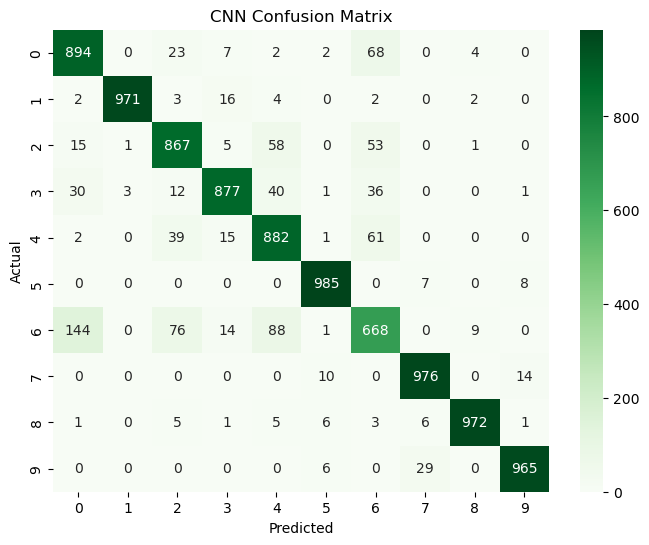

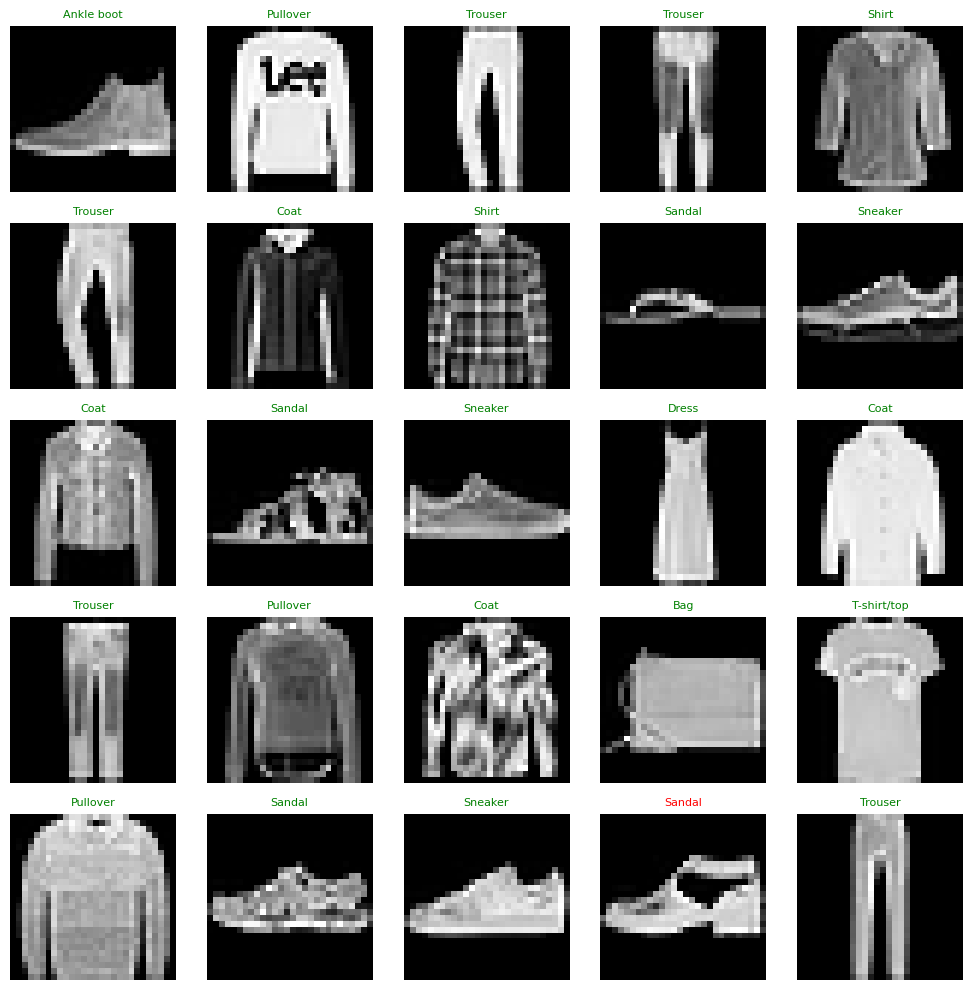

In [11]:
y_pred_cnn = np.argmax(
    model_cnn.predict(x_test_cnn),
    axis=1
)


print(classification_report(
    y_test,
    y_pred_cnn
))


cm_cnn = confusion_matrix(
    y_test,
    y_pred_cnn
)


plt.figure(figsize=(8,6))

sns.heatmap(
    cm_cnn,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()



# Sample Predictions

plt.figure(figsize=(10,10))

for i in range(25):

    plt.subplot(5,5,i+1)

    plt.imshow(
        x_test[i],
        cmap="gray"
    )

    plt.axis("off")

    color = "green" if y_test[i]==y_pred_cnn[i] else "red"

    plt.title(
        class_names[y_pred_cnn[i]],
        color=color,
        fontsize=8
    )


plt.tight_layout()
plt.show()